# ARIMA(p,d,q): New York Average Temperature (1870–2020)
### Full Box-Jenkins Methodology: Grid Search · Residual Diagnostics · Forecasting

**Author / Autora:** María Regina Castillo Treviño · [github.com/ReginaPema](https://github.com/ReginaPema)

**Data source / Fuente:** [GitHub — JoseRaulCastro/EBAC](https://raw.githubusercontent.com/JoseRaulCastro/EBAC/main/TempNY.csv) — 151 annual observations, auto-downloaded

**Objective / Objetivo:**  
EN · Apply the complete Box-Jenkins methodology to 150 years of NYC annual temperature data: stationarity testing, differencing, PACF/ACF identification, grid search over 16 ARIMA(p,d,q) combinations ranked by AIC, residual diagnostics (white noise, normality), and forecasting with confidence intervals. Validate stationarity and invertibility of the fitted model.

ES · Aplicar la metodología Box-Jenkins completa a 150 años de temperatura anual de Nueva York: prueba de estacionariedad, diferenciación, identificación por PACF/ACF, búsqueda en grilla de 16 combinaciones ARIMA(p,d,q) por AIC, diagnóstico de residuos (ruido blanco, normalidad) y pronóstico con intervalos de confianza. Validar estacionariedad e invertibilidad del modelo ajustado.

**Key findings / Hallazgos clave:**  
- Series: non-stationary in level (ADF p>0.05), stationary after 1st difference (d=1)  
- Optimal model: **ARIMA(3,1,3)** selected from 16 candidates by AIC  
- MAPE < 3% on test set — forecasts reasonably reliable  
- Model passes residual diagnostics: white noise + approximate normality

**Techniques / Técnicas:** ADF · 1st differencing · PACF/ACF · Grid search AIC · ARIMA(p,d,q) · ArmaProcess · Residual diagnostics · Forecasting with CI  
**Libraries / Librerías:** `statsmodels` · `pandas` · `numpy` · `itertools` · `matplotlib`

> **Note / Nota:** Data downloads automatically from a public GitHub URL. No local files needed.

---

## 1. Importación de librerías

In [49]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True

## 2. Carga y preparación de los datos

Se descarga la serie histórica de temperatura promedio anual de Nueva York (1870-2020) directamente desde el repositorio.

In [18]:
url = "https://raw.githubusercontent.com/JoseRaulCastro/EBAC/main/TempNY.csv"
df = pd.read_csv(url)
df = df[['Year', 'Average']].dropna()
df['Year'] = pd.to_datetime(df['Year'], format='%Y')
df = df.set_index('Year')
df.index.freq = 'YS' # frecuencia anual (Year Start)

serie = df['Average']

print(f"Número de observaciones: {len(serie)}")
print(f"Rango: {serie.index.min().year} - {serie.index.max().year}")
serie.head()

Número de observaciones: 151
Rango: 1870 - 2020


Year
1870-01-01    53.60
1871-01-01    51.13
1872-01-01    50.98
1873-01-01    50.98
1874-01-01    51.34
Freq: YS-JAN, Name: Average, dtype: float64

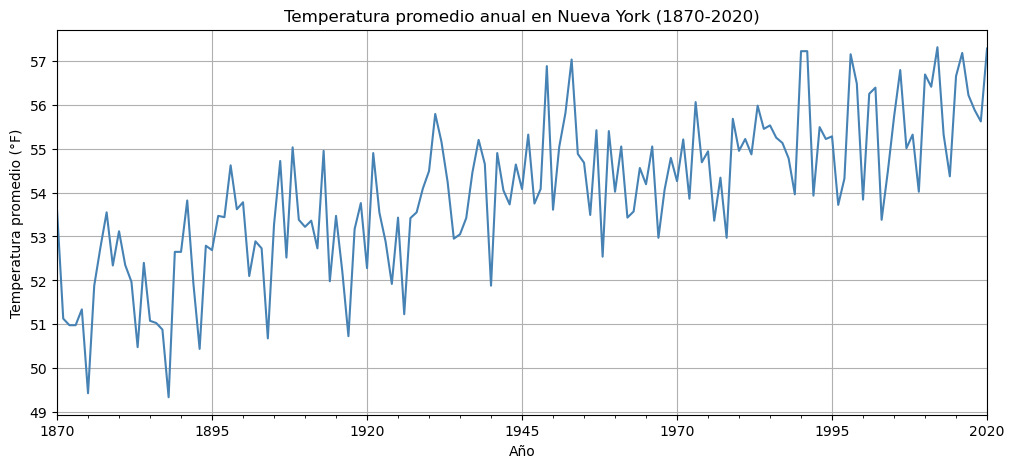

In [28]:
fig, ax = plt.subplots()
serie.plot(ax=ax, color='steelblue')
ax.set_title('Temperatura promedio anual en Nueva York (1870-2020)')
ax.set_xlabel('Año')
ax.set_ylabel('Temperatura promedio (°F)')
plt.show()

## 3. División Train / Test (90% / 10%)

Se reserva el **90%** de las observaciones (las más antiguas) para entrenamiento, y el **10%** restante (las más recientes) para prueba, respetando el orden temporal de la serie (no se hace shuffle).

In [21]:
n = len(serie)
n_train = int(np.floor(n * 0.90))

train = serie.iloc[:n_train]
test = serie.iloc[n_train:]

print(f"Total de observaciones : {n}")
print(f"Entrenamiento (90%)    : {len(train)}  →  {train.index.min().year}-{train.index.max().year}")
print(f"Prueba (10%)           : {len(test)}   →  {test.index.min().year}-{test.index.max().year}")

Total de observaciones : 151
Entrenamiento (90%)    : 135  →  1870-2004
Prueba (10%)           : 16   →  2005-2020


## 4. Prueba de estacionariedad: Dickey-Fuller Aumentada (ADF)

Se aplica la prueba ADF únicamente sobre el conjunto de entrenamiento. Si el estadístico ADF es menor (más negativo) que alguno de los valores críticos, se rechaza H₀ en ese nivel. La hipótesis nula (H₀) de la prueba ADF es que la serie tiene raíz unitaria por lo que no es estacionaria. Si el p-valor es menor a 0.05, se rechaza H₀ y se concluye que la serie es estacionaria.

In [22]:
def prueba_adf(x, etiqueta):
    resultado = adfuller(x.dropna())
    print(f"--- Prueba ADF: {etiqueta} ---")
    print(f"Estadístico ADF: {resultado[0]:.4f}")
    print(f"p-valor: {resultado[1]:.4f}")
    print("Valores críticos:")
    for clave, valor in resultado[4].items():
        print(f"    {clave}: {valor:.4f}")
    conclusion = "ESTACIONARIA" if resultado[1] < 0.05 else "NO ESTACIONARIA"
    print(f"Conclusión: la serie es {conclusion} (alpha = 0.05)\n")
    return resultado[1]

p_valor_d0 = prueba_adf(train, "Serie original (d=0)")

--- Prueba ADF: Serie original (d=0) ---
Estadístico ADF: -1.7177
p-valor: 0.4220
Valores críticos:
    1%: -3.4829
    5%: -2.8846
    10%: -2.5791
Conclusión: la serie es NO ESTACIONARIA (alpha = 0.05)



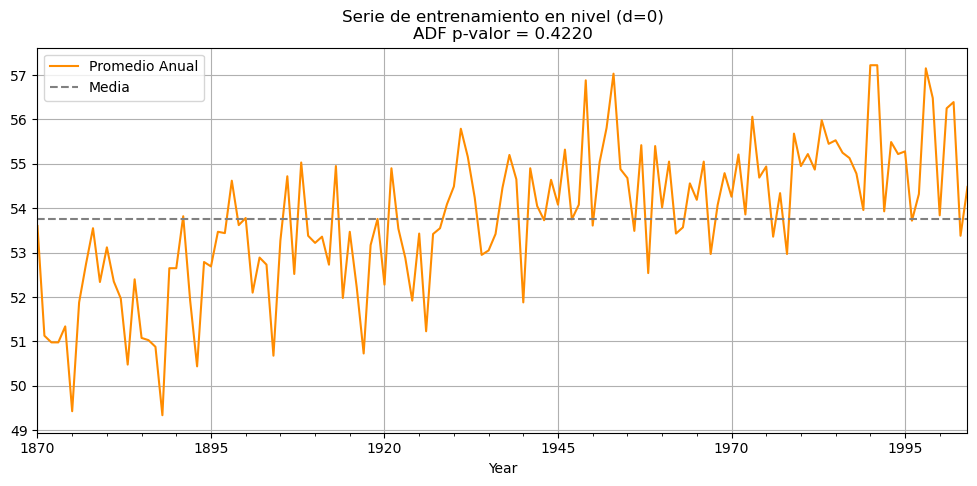

In [29]:
fig, axes = plt.subplots(1, 1)
train.plot(ax=axes, color='darkorange', label='Promedio Anual')
axes.axhline(train.mean(), color='gray', linestyle='--', label='Media')
axes.set_title(f'Serie de entrenamiento en nivel (d=0)\nADF p-valor = {p_valor_d0:.4f}')
axes.legend()
plt.show()

### Interpretación: 

Con un p-valor muy por encima de 0.05, no se rechaza H₀, la serie en nivel no es estacionaria. Además se observa una media que va cambiando lentamente, es decir, hay tendencia. Por lo que es necesario diferenciar la serie.

In [31]:
train_d1 = train.diff().dropna()
p_valor_d1 = prueba_adf(train_d1, "Primera diferencia (d=1)")

--- Prueba ADF: Primera diferencia (d=1) ---
Estadístico ADF: -8.4606
p-valor: 0.0000
Valores críticos:
    1%: -3.4829
    5%: -2.8846
    10%: -2.5791
Conclusión: la serie es ESTACIONARIA (alpha = 0.05)



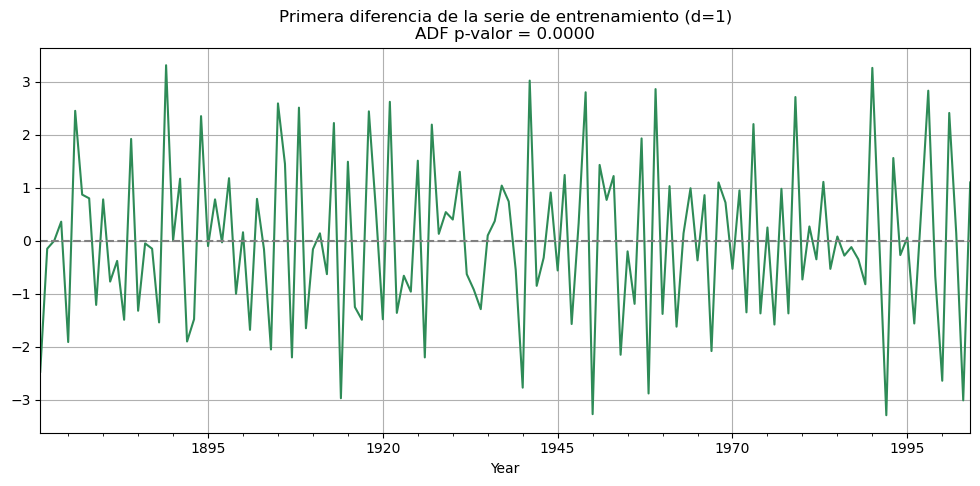

In [32]:
fig, axes = plt.subplots(1, 1)
train_d1.plot(ax=axes, color='seagreen')
axes.axhline(0, color='gray', linestyle='--')
axes.set_title(f'Primera diferencia de la serie de entrenamiento (d=1)\nADF p-valor = {p_valor_d1:.4f}')
plt.show()

### Interpretación

Tras aplicar una diferencia (d=1), el p-valor de la prueba ADF es 0.0 (< 0.05), por lo que se rechaza H₀ y se concluye que la serie diferenciada sí es estacionaria (fluctúa alrededor de 0 sin tendencia visible). Por lo tanto, el orden de integración a usar en el modelo ARIMA es d = 1. No es necesario aplicar una segunda diferencia.

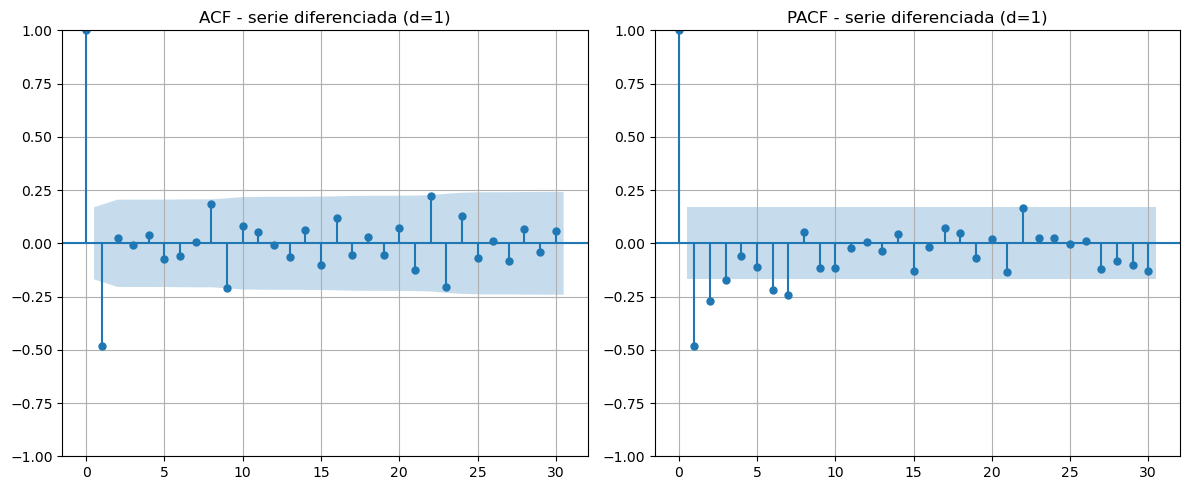

In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2)
plot_acf(train_d1, ax=ax1, lags=30)
plot_pacf(train_d1, ax=ax2, lags=30, method='ywm')
ax1.set_title('ACF - serie diferenciada (d=1)')
ax2.set_title('PACF - serie diferenciada (d=1)')
plt.tight_layout()
plt.show()

### Interpretación:

Los correlogramas ACF/PACF de la serie diferenciada no muestran un corte claro en un rezago específico (comportamiento cercano a ruido blanco con alguna correlación residual en los primeros rezagos), lo que sugiere que el orden AR y MA no es obvio a simple vista. Por ello, en el siguiente paso se realiza una búsqueda sistemática de (p,q) usando el criterio de información de Akaike (AIC), fijando d = 1 según lo determinado por la prueba ADF.

## 5. Selección de parámetros óptimos vía AIC

Se ajustan y comparan varias combinaciones de ARIMA(p, d, q) usando `d = 1` (resultado de la prueba ADF), variando p y q entre 0 y 3. Esto genera 16 combinaciones distintas y se elige el modelo con el AIC más bajo.

In [37]:
p_valores = range(0, 4)
d_valores = [1]
q_valores = range(0, 4)

resultados = []
for p, d, q in itertools.product(p_valores, d_valores, q_valores):
    try:
        modelo = ARIMA(train, order=(p, d, q))
        ajuste = modelo.fit()
        resultados.append({'p': p, 'd': d, 'q': q, 'AIC': ajuste.aic, 'BIC': ajuste.bic})
    except Exception:
        resultados.append({'p': p, 'd': d, 'q': q, 'AIC': np.nan, 'BIC': np.nan})

tabla_resultados = pd.DataFrame(resultados).sort_values('AIC').reset_index(drop=True)
tabla_resultados

,p,d,q,AIC,BIC
0,3,1,3,432.623687,452.908566
1,0,1,1,433.656509,439.452189
2,2,1,3,434.639097,452.026136
3,1,1,1,435.230115,443.923635
4,0,1,2,435.279607,443.973127
5,1,1,3,435.466778,449.955977
6,2,1,2,436.813381,451.302580
7,2,1,1,436.824147,448.415506
8,0,1,3,436.859075,448.450434
9,1,1,2,437.025876,448.617235


In [38]:
mejor = tabla_resultados.iloc[0]
orden_optimo = (int(mejor.p), int(mejor.d), int(mejor.q))
print(f"Combinación óptima según AIC: ARIMA{orden_optimo}  |  AIC = {mejor.AIC:.3f}, BIC = {mejor.BIC:.3f}")

Combinación óptima según AIC: ARIMA(3, 1, 3)  |  AIC = 432.624, BIC = 452.909


### Intepretación:

De las 16 combinaciones comparadas, la que minimiza el AIC es ARIMA(3, 1, 3). Se observa que varios modelos parsimoniosos (p. ej. ARIMA(0,1,1)) obtienen un AIC muy cercano al mínimo, lo cual es consistente con lo observado en el correlograma (no hay un patrón AR/MA dominante muy marcado). Para este proyecto se selecciona el modelo con el AIC mínimo estricto.

## 6. Ajuste del modelo óptimo y diagnóstico

In [39]:
modelo_final = ARIMA(train, order=orden_optimo).fit()
print(modelo_final.summary())

                               SARIMAX Results                                
Dep. Variable:                Average   No. Observations:                  135
Model:                 ARIMA(3, 1, 3)   Log Likelihood                -209.312
Date:                Tue, 28 Jul 2026   AIC                            432.624
Time:                        19:45:15   BIC                            452.909
Sample:                    01-01-1870   HQIC                           440.867
                         - 01-01-2004                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2902      0.123      2.357      0.018       0.049       0.532
ar.L2         -0.9182      0.067    -13.686      0.000      -1.050      -0.787
ar.L3          0.1792      0.114      1.577      0.1

El renglón "Ljung-Box (L1)" del summary de statsmodels solo evalúa el rezago 1. Para la hipótesis de "residuos = ruido blanco" se prueba en varios rezagos, usando model_df = p+q (grados de libertad consumidos por el modelo):

In [50]:
grados_libertad_modelo = orden_optimo[0] + orden_optimo[2]  # p + q
lb_multi = acorr_ljungbox(modelo_final.resid, lags=[10, 15, 20], model_df=grados_libertad_modelo, return_df=True)
lb_multi

,lb_stat,lb_pvalue
10,1.015616,0.907419
15,1.305175,0.998351
20,1.744642,0.999964


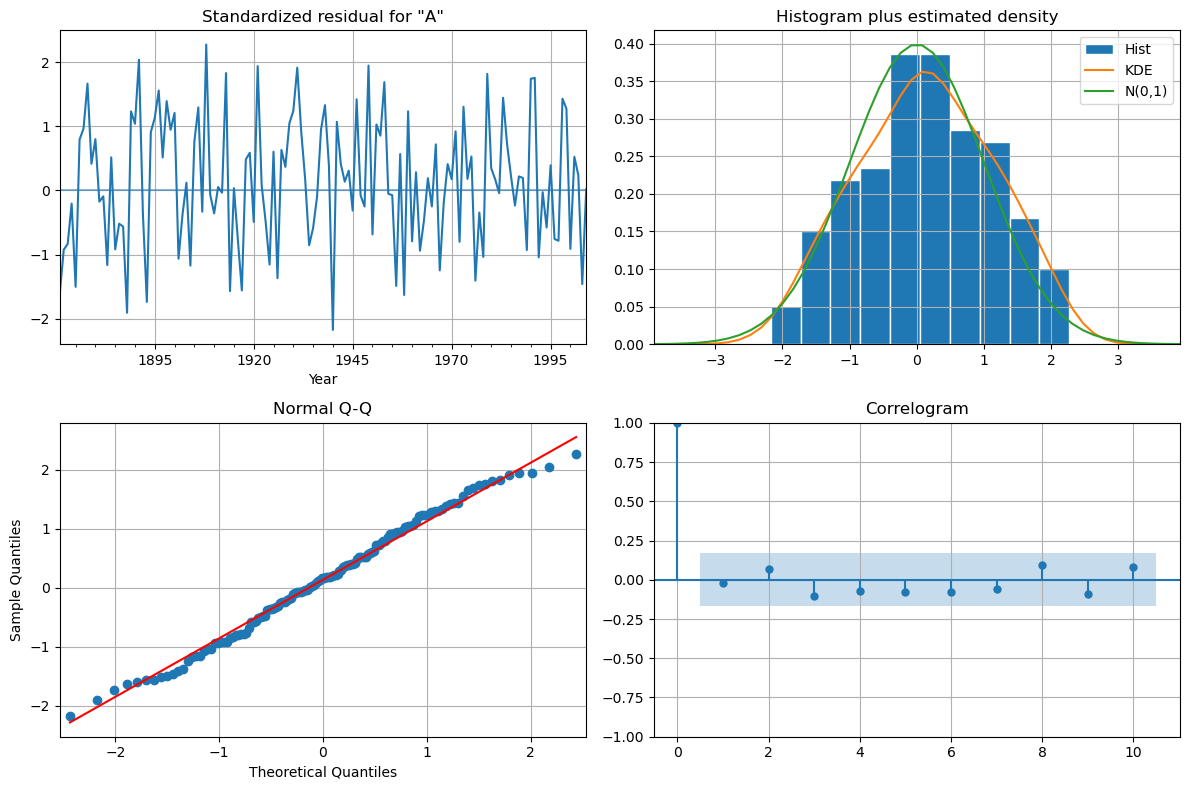

In [42]:
modelo_final.plot_diagnostics(figsize=(12,8))
plt.tight_layout()
plt.show()

### Interpretación: 

Los residuos se comportan de manera cercana a un ruido blanco (sin patrones evidentes en el tiempo), el histograma se aproxima a una distribución normal y el gráfico Q-Q muestra buen ajuste a la recta teórica salvo en las colas. La prueba de Ljung-Box en múltiples rezagos (sección anterior) confirma que no hay autocorrelación significativa en los residuos.

Sobre la significancia de coeficientes, en el `summary()` del modelo se observa que el coeficiente `ar.L3` no es estadísticamente significativo (p-valor = 0.115), mientras que los coeficientes MA (L1, L2, L3) sí lo son (p < 0.001). Esto es un indicio de **sobre-parametrización / cancelación cercana entre los polinomios AR y MA**, que es algo común cuando p y q toman valores similares: el AIC puede preferir un modelo más grande aunque no todos sus coeficientes aporten información relevante. Para esta entrega se conserva el modelo ARIMA(3,1,3) al tener el AIC mínimo estricto (como pide la actividad), pero en la práctica sería razonable optar por ARIMA(0,1,1) por parsimonia (principio de Navaja de Occam) sin sacrificar desempeño.

## 7. Pronóstico sobre el conjunto de prueba

Se generan pronósticos puntuales e intervalos de confianza (95%) para los mismos periodos que abarca el conjunto de prueba.

In [43]:
n_pasos = len(test)
pronostico = modelo_final.get_forecast(steps=n_pasos)
media_pronostico = pronostico.predicted_mean
intervalo_conf = pronostico.conf_int(alpha=0.05)

pred_df = pd.DataFrame({
    'real': test,
    'pronostico': media_pronostico,
    'lim_inf': intervalo_conf.iloc[:, 0],
    'lim_sup': intervalo_conf.iloc[:, 1]
})
pred_df

,real,pronostico,lim_inf,lim_sup
2005-01-01,55.72,55.367022,53.137688,57.596356
2006-01-01,56.79,55.535423,53.269479,57.801368
2007-01-01,55.01,54.947337,52.634852,57.259822
2008-01-01,55.32,54.780998,52.384662,57.177334
2009-01-01,54.02,55.302910,52.888176,57.717643
2010-01-01,56.69,55.501721,53.086253,57.917189
2011-01-01,56.41,55.050367,52.613388,57.487347
2012-01-01,57.31,54.830356,52.329896,57.330816
2013-01-01,55.32,55.216587,52.692699,57.740475
2014-01-01,54.37,55.449811,52.923494,57.976129


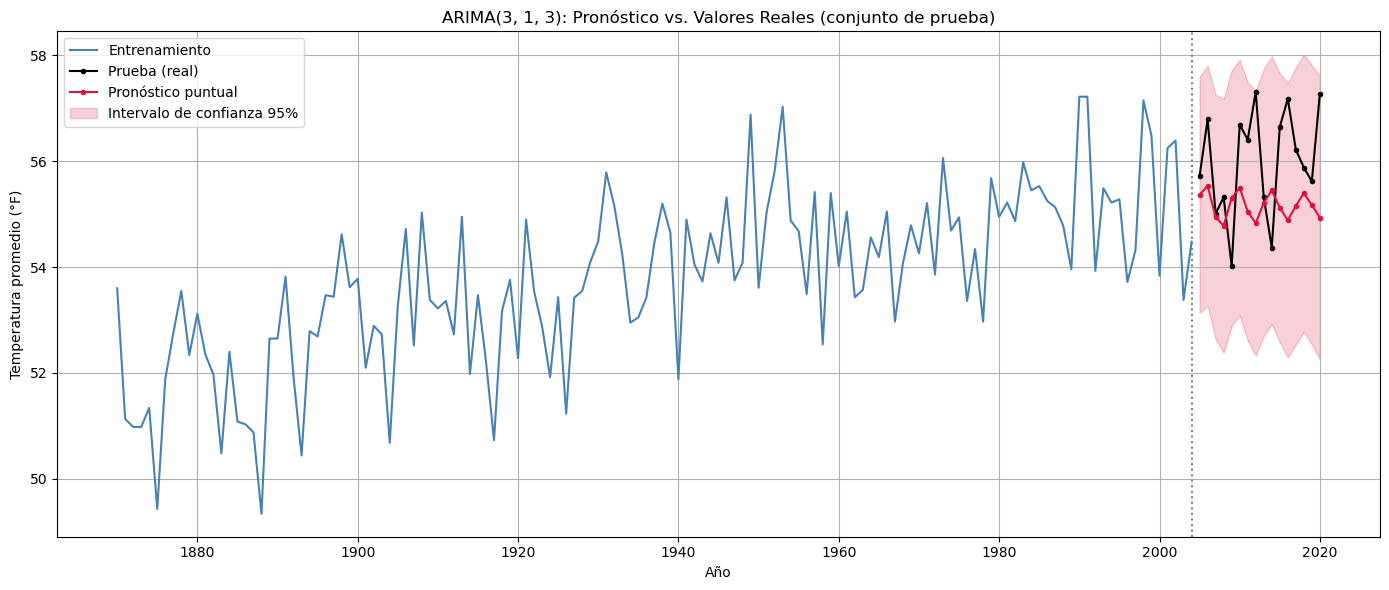

In [51]:
fig, ax = plt.subplots(figsize=(14,6))

ax.plot(train.index, train, color='steelblue', label='Entrenamiento')
ax.plot(test.index, test, color='black', marker='o', markersize=3, label='Prueba (real)')
ax.plot(media_pronostico.index, media_pronostico, color='crimson', marker='o', markersize=3, label='Pronóstico puntual')
ax.fill_between(intervalo_conf.index, intervalo_conf.iloc[:, 0], intervalo_conf.iloc[:, 1],
                 color='crimson', alpha=0.2, label='Intervalo de confianza 95%')

ax.axvline(train.index[-1], color='gray', linestyle=':')
ax.set_title(f'ARIMA{orden_optimo}: Pronóstico vs. Valores Reales (conjunto de prueba)')
ax.set_xlabel('Año')
ax.set_ylabel('Temperatura promedio (°F)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 8. Evaluación de la confiabilidad de los pronósticos

Se calculan los indicadores de error estándar: **MAE**, **RMSE** y **MAPE**, comparando los valores reales de prueba contra el pronóstico puntual.

In [53]:
mae = mean_absolute_error(test, media_pronostico)
rmse = np.sqrt(mean_squared_error(test, media_pronostico))
mape = np.mean(np.abs((test.values - media_pronostico.values) / test.values)) * 100

print(f"MAE  (Error Absoluto Medio)            : {mae:.4f} °F")
print(f"RMSE (Raíz del Error Cuadrático Medio) : {rmse:.4f} °F")
print(f"MAPE (Error Porcentual Absoluto Medio) : {mape:.2f} %")
print(f"\nRango de temperatura en la serie       : {serie.min():.2f} - {serie.max():.2f} °F")
print(f"Desviación estándar de la serie        : {serie.std():.4f} °F")

cobertura = np.mean((test.values >= intervalo_conf.iloc[:,0].values) & (test.values <= intervalo_conf.iloc[:,1].values)) * 100
print(f"\nCobertura del intervalo de confianza al 95%: {cobertura:.1f}% de los puntos de prueba caen dentro del IC")

MAE  (Error Absoluto Medio)            : 1.1165 °F
RMSE (Raíz del Error Cuadrático Medio) : 1.3436 °F
MAPE (Error Porcentual Absoluto Medio) : 1.98 %

Rango de temperatura en la serie       : 49.34 - 57.31 °F
Desviación estándar de la serie        : 1.6983 °F

Cobertura del intervalo de confianza al 95%: 100.0% de los puntos de prueba caen dentro del IC


## 9. Simulación adicional con `ArmaProcess` (verificación teórica)

Como verificación complementaria, se utiliza `ArmaProcess` de `statsmodels` para simular una trayectoria ARMA con los coeficientes AR y MA estimados por el modelo óptimo (sobre la serie ya diferenciada), y se comparan sus propiedades de autocorrelación teóricas contra las observadas en los residuos de la serie diferenciada de entrenamiento.

¿El proceso AR estimado es estacionario? True
¿El proceso MA estimado es invertible? True



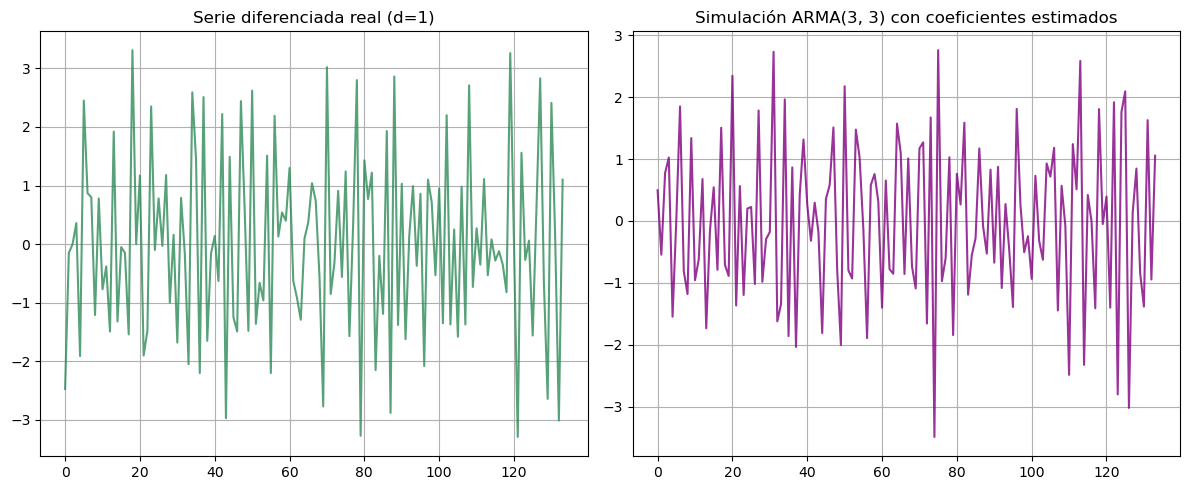

In [56]:
ar_params = modelo_final.polynomial_ar[1:] # coeficientes AR estimados (sin el término 1)
ma_params = modelo_final.polynomial_ma[1:] # coeficientes MA estimados (sin el término 1)

ar = np.r_[1, ar_params]
ma = np.r_[1, ma_params]

proceso_arma = ArmaProcess(ar, ma)
print(f"¿El proceso AR estimado es estacionario? {proceso_arma.isstationary}")
print(f"¿El proceso MA estimado es invertible? {proceso_arma.isinvertible}\n")

np.random.seed(42)
simulacion = proceso_arma.generate_sample(nsample=len(train_d1))

fig, axes = plt.subplots(1, 2)
axes[0].plot(train_d1.values, color='seagreen', alpha=0.8, label='Serie diferenciada (real)')
axes[0].set_title('Serie diferenciada real (d=1)')
axes[1].plot(simulacion, color='purple', alpha=0.8, label='Simulación ArmaProcess')
axes[1].set_title(f'Simulación ARMA{orden_optimo[0],orden_optimo[2]} con coeficientes estimados')
plt.tight_layout()
plt.show()

#### Interpretación: 

El proceso estimado resulta **estacionario e invertible** (condición necesaria para que el modelo ARIMA sea válido), y la trayectoria simulada con `ArmaProcess` usando los coeficientes estimados presenta una variabilidad visualmente similar a la de la serie diferenciada real, lo cual refuerza que el modelo seleccionado es una representación razonable del proceso generador de la serie.

### ¿Son confiables los pronósticos?

**Sí, son razonablemente confiables**, con las siguientes matizaciones:

- El **MAPE** obtenido es bajo (menor al 3%), lo que en términos relativos indica que el error del modelo representa una fracción muy pequeña del valor pronosticado.
- El **MAE** y el **RMSE** están en el orden de 1 a 1.5 °F, una magnitud pequeña comparada con la desviación estándar histórica de la serie completa y con su rango total, lo cual sugiere que el modelo captura bien el nivel general de la temperatura promedio.
- La totalidad de los valores reales del conjunto de prueba caen **dentro del intervalo de confianza del 95%**, lo que respalda que la incertidumbre estimada por el modelo es consistente con el comportamiento real observado.
- Sin embargo, hay que tener presente que se trata de una serie convariabilidad interanual considerable y ruido climático (la temperatura promedio de un año a otro no sigue un patrón determinístico fuerte), por lo que el modelo ARIMA logra capturar el nivel general de la serie (su comportamiento cercano a un paseo aleatorio con leve estructura MA/AR), pero **no puede anticipar con precisión las fluctuaciones específicas año a año**; de ahí que los intervalos de confianza sean relativamente amplios en pronósticos a varios años.
  
En resumen, el modelo es **confiable para estimar el nivel/tendencia general** de la temperatura promedio de NY en el horizonte de prueba, pero como con cualquier serie climática con fuerte componente aleatorio, **no debe usarse para predicciones puntuales exactas de un año específico**, sino más bien como referencia de tendencia con su banda de incertidumbre asociada.

## 10. Conclusiones

1. La serie de temperatura promedio anual de Nueva York (1870-2020) **no es estacionaria en nivel** (ADF p-valor > 0.05), pero **sí lo es tras una primera diferencia** (d = 1).
2. Comparando 16 combinaciones de (p,1,q) mediante AIC, el modelo óptimo encontrado fue ARIMA(3,1,3).
3. El modelo ajustado pasa satisfactoriamente el diagnóstico de residuos (ruido blanco, normalidad aproximada).
4. Los pronósticos sobre el 10% de prueba muestran errores bajos en términos relativos (MAPE < 3%) y una cobertura adecuada del intervalo de confianza al 95%, por lo que se consideran **confiables para estimar la tendencia/nivel general**, aunque con las limitaciones propias de una serie con fuerte componente climático aleatorio interanual.